In [1]:
# Levi Félix Barbosa - 579420
 
import numpy as np
import matplotlib.pyplot as plt
 

# separar e normalizar os dados

 
vehicle = np.genfromtxt('vehicle.csv', delimiter=',')
X = vehicle[:, :-1]
y = vehicle[:, -1].astype(int)
 

valores_unicos = sorted(np.unique(y))
classe_para_idx = {c: i for i, c in enumerate(valores_unicos)}
y = np.array([classe_para_idx[c] for c in y])
classes = [str(c) for c in valores_unicos]  
K = len(classes)                             
 
N = len(X)
tam_treino = int(0.6 * N)
tam_val    = int(0.2 * N)
tam_teste  = N - tam_treino - tam_val
 
np.random.seed(42)
indices = np.random.permutation(N)
X = X[indices]
y = y[indices]
 
X_treino = X[:tam_treino]
y_treino = y[:tam_treino]
 
X_val  = X[tam_treino:tam_treino + tam_val]
y_val  = y[tam_treino:tam_treino + tam_val]
 
X_teste = X[tam_treino + tam_val:]
y_teste = y[tam_treino + tam_val:]
 
# normalização usando dados do treino
media_x  = np.mean(X_treino, axis=0)
desvio_x = np.std(X_treino,  axis=0)
desvio_x[desvio_x == 0] = 1  # cuidado na divisao por zero
 
X_treino_norm = (X_treino - media_x) / desvio_x
X_val_norm    = (X_val    - media_x) / desvio_x
X_teste_norm  = (X_teste  - media_x) / desvio_x

In [2]:
def one_hot(y, K):
    
    N = len(y)
    Y = np.zeros((N, K))
    Y[np.arange(N), y] = 1
    return Y
 
def inicializar_pesos(NH, D, K):
    W = np.sqrt(1.0 / D) * np.random.randn(NH, D + 1)
    W[:, 0] = 0
    M = np.sqrt(1.0 / NH) * np.random.randn(K, NH + 1)
    M[:, 0] = 0
    return W, M
 
def softmax(R):
    eR = np.exp(R - np.max(R, axis=1, keepdims=True))
    return eR / np.sum(eR, axis=1, keepdims=True)
 
def forward(X, W, M):
    N = X.shape[0]
    X_aum = np.hstack((np.ones((N, 1)), X))
    U     = X_aum @ W.T
    Z     = np.tanh(U)
    Z_aum = np.hstack((np.ones((N, 1)), Z))
    R     = Z_aum @ M.T
    O     = softmax(R)          
    return X_aum, Z, Z_aum, O
 
def calcular_custo(Y_onehot, O):
    N = Y_onehot.shape[0]
    J = -np.sum(Y_onehot * np.log(O + 1e-9)) / N
    return J
 
def backward(X_aum, Y_onehot, Z, Z_aum, O, M):
    N = X_aum.shape[0]
    delta  = (O - Y_onehot) / N                     
    zeta   = (1 - Z**2) * (delta @ M[:, 1:])        
    grad_M = delta.T @ Z_aum                          
    grad_W = zeta.T  @ X_aum                          
    return grad_W, grad_M
 
def gerar_mini_batches(X, y, tamanho_batch):
    N = X.shape[0]
    indices = np.random.permutation(N)
    X_emb = X[indices]
    y_emb = y[indices]
    mini_batches = []
    for i in range(0, N, tamanho_batch):
        X_batch = X_emb[i:i + tamanho_batch]
        y_batch = y_emb[i:i + tamanho_batch]
        mini_batches.append((X_batch, y_batch))
    return mini_batches
 
def atualizar_pesos(W, M, grad_W, grad_M, v_w, v_m, alpha, mu=0.9):
    v_w = mu * v_w - alpha * grad_W
    v_m = mu * v_m - alpha * grad_M
    W   = W + v_w
    M   = M + v_m
    return W, M, v_w, v_m
 

def treinar_mlp(X_treino, y_treino, X_val, y_val, NH, K,
                epocas, alpha, mu, tamanho_batch, paciencia=None):
 
    D = X_treino.shape[1]
    W, M = inicializar_pesos(NH, D, K)
    v_w  = np.zeros_like(W)
    v_m  = np.zeros_like(M)
 
    Y_treino_oh = one_hot(y_treino, K)
    Y_val_oh    = one_hot(y_val,    K)
 
    historico_treino = []
    historico_val    = []
 
    melhor_custo_val = float('inf')
    melhores_pesos   = (W.copy(), M.copy())
    epocas_ruins     = 0
 
    for epoca in range(epocas):
 
        mini_batches = gerar_mini_batches(X_treino, y_treino, tamanho_batch)
 
        for X_batch, y_batch in mini_batches:
            Y_batch_oh = one_hot(y_batch, K)
            X_aum, Z, Z_aum, O = forward(X_batch, W, M)
            grad_W, grad_M     = backward(X_aum, Y_batch_oh, Z, Z_aum, O, M)
            W, M, v_w, v_m     = atualizar_pesos(W, M, grad_W, grad_M,
                                                  v_w, v_m, alpha, mu)
 
        # avaliação ao final da época
        _, _, _, O_treino = forward(X_treino, W, M)
        custo_treino = calcular_custo(Y_treino_oh, O_treino)
        historico_treino.append(custo_treino)
 
        _, _, _, O_val = forward(X_val, W, M)
        custo_val = calcular_custo(Y_val_oh, O_val)
        historico_val.append(custo_val)
 
        # early stopping
        if paciencia is not None:
            if custo_val < melhor_custo_val:
                melhor_custo_val = custo_val
                melhores_pesos   = (W.copy(), M.copy())
                epocas_ruins     = 0
            else:
                epocas_ruins += 1
            if epocas_ruins >= paciencia:
                print(f"early stopping na época {epoca+1}")
                W, M = melhores_pesos
                break
 
        if (epoca + 1) % max(1, (epocas // 10)) == 0:
            print(f"Época {epoca+1:04d}/{epocas} / Custo Treino: {custo_treino:.4f} / Custo Val: {custo_val:.4f}")
 
    if paciencia is not None:
        W, M = melhores_pesos
 
    return W, M, historico_treino, historico_val
 
 
def calcular_metricas_q2(y_real, y_pred, K):
    
    # vai dar acuracia, precisoes, revocaçoes, e f1s
    acuracia = np.mean(y_real == y_pred)
 
    precisoes  = []
    revocacoes = []
    f1s        = []
 
    for k in range(K):
        tp = np.sum((y_pred == k) & (y_real == k))
        fp = np.sum((y_pred == k) & (y_real != k))
        fn = np.sum((y_pred != k) & (y_real == k))
 
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rev  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = (2 * prec * rev / (prec + rev)) if (prec + rev) > 0 else 0.0
 
        precisoes.append(prec)
        revocacoes.append(rev)
        f1s.append(f1)
 
    return acuracia, np.mean(precisoes), np.mean(revocacoes), np.mean(f1s)
 
def matriz_confusao(y_real, y_pred, K):
    C = np.zeros((K, K), dtype=int)
    for real, pred in zip(y_real, y_pred):
        C[real][pred] += 1
    return C
 
def plotar_curvas(historico_treino, historico_val):
    plt.figure(figsize=(9, 5))
    plt.plot(historico_treino, label='Custo de Treinamento', color='blue',   linewidth=2)
    plt.plot(historico_val,    label='Custo de Validação',   color='orange', linewidth=2)
    plt.title('Curva da Função Custo ao Longo das Épocas', fontsize=12)
    plt.xlabel('Épocas', fontsize=10)
    plt.ylabel('Custo (J)',  fontsize=10)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
 
def plotar_matriz_confusao(C, classes):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C, cmap='Blues')
    plt.colorbar(im, ax=ax)
 
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel('Predito',  fontsize=11)
    ax.set_ylabel('Real',     fontsize=11)
    ax.set_title('Matriz de Confusão — Conjunto de Teste', fontsize=12)
 
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(C[i, j]),
                    ha='center', va='center',
                    color='white' if C[i, j] > C.max() / 2 else 'black',
                    fontsize=13)
    plt.tight_layout()
    plt.show()

Random Search na validação

Tentativa 1/15 | alpha=0.00124, mu=0.89, NH=50
Época 0050/500 / Custo Treino: 0.6547 / Custo Val: 0.7538
Época 0100/500 / Custo Treino: 0.5133 / Custo Val: 0.6279
Época 0150/500 / Custo Treino: 0.4443 / Custo Val: 0.5658
Época 0200/500 / Custo Treino: 0.4013 / Custo Val: 0.5294
Época 0250/500 / Custo Treino: 0.3704 / Custo Val: 0.5059
Época 0300/500 / Custo Treino: 0.3463 / Custo Val: 0.4875
Época 0350/500 / Custo Treino: 0.3260 / Custo Val: 0.4783
Época 0400/500 / Custo Treino: 0.3083 / Custo Val: 0.4704
Época 0450/500 / Custo Treino: 0.2923 / Custo Val: 0.4670
Época 0500/500 / Custo Treino: 0.2777 / Custo Val: 0.4641
   -> Acurácia de validação: 0.7929
Tentativa 2/15 | alpha=0.00656, mu=0.61, NH=10
Época 0050/500 / Custo Treino: 0.6590 / Custo Val: 0.8004
Época 0100/500 / Custo Treino: 0.5093 / Custo Val: 0.6498
Época 0150/500 / Custo Treino: 0.4382 / Custo Val: 0.5736
Época 0200/500 / Custo Treino: 0.3963 / Custo Val: 0.5229
Época 0250/500 / Custo Treino:

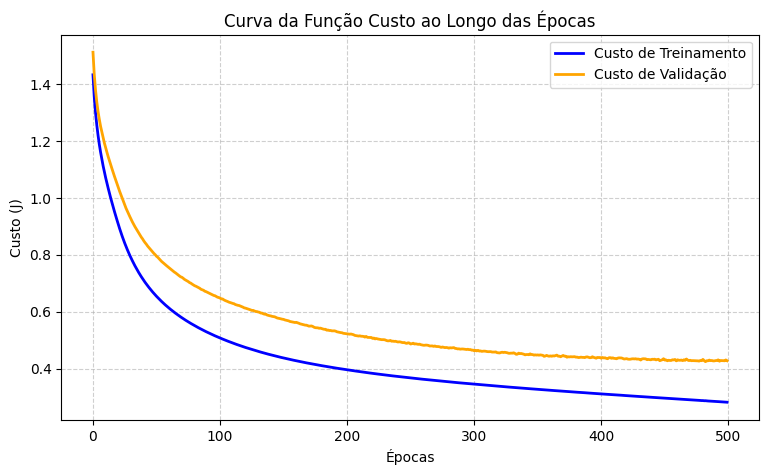

Métricas finais:
Conjunto        | Acurácia   | Precisão   | Revocação  | F1        
Treinamento     | 0.8856     | 0.8791     | 0.8789     | 0.8787    
Validação       | 0.8166        | 0.8333        | 0.8148        | 0.8128    
Teste           | 0.7294        | 0.7741        | 0.7780        | 0.7577    

Matriz de Confusão (Teste):
             0       1       2       3
     0      34       1       1       0
     1       1      28      31       2
     2       0       9      26       0
     3       0       0       1      36


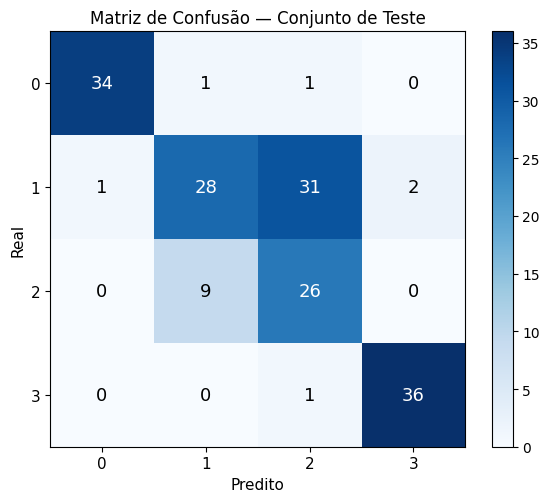

In [3]:
np.random.seed(67)
rodadas_de_busca = 15
 
melhor_acuracia_val = -float('inf')
config_otima  = {}
pesos_otimos  = None
historico_otimo = None
 
print("Random Search na validação\n")
 
for rodada in range(rodadas_de_busca):
 
    alpha_cand      = 10 ** np.random.uniform(-4, -2)      # escala logarítmica
    mu_cand         = np.random.uniform(0.5, 0.95)
    nh_cand         = int(np.random.choice([10, 20, 30, 50]))
    tamanho_batch   = 32
 
    print(f"Tentativa {rodada+1}/{rodadas_de_busca} | alpha={alpha_cand:.5f}, mu={mu_cand:.2f}, NH={nh_cand}")
 
    W, M, h_treino, h_val = treinar_mlp(
        X_treino_norm, y_treino,
        X_val_norm,    y_val,
        NH=nh_cand, K=K,
        epocas=500,
        alpha=alpha_cand,
        mu=mu_cand,
        tamanho_batch=tamanho_batch,
        paciencia=40
    )
 
    # avaliar no conjunto de validação
    _, _, _, O_val_cand = forward(X_val_norm, W, M)
    y_pred_val = np.argmax(O_val_cand, axis=1)
    acc_val    = np.mean(y_pred_val == y_val)
    print(f"   -> Acurácia de validação: {acc_val:.4f}")
 
    if acc_val > melhor_acuracia_val:
        melhor_acuracia_val = acc_val
        config_otima  = {'alpha': alpha_cand, 'mu': mu_cand, 'NH': nh_cand, 'batch': tamanho_batch}
        pesos_otimos  = (W.copy(), M.copy())
        historico_otimo = (h_treino, h_val)
 
print(f"\nMelhor configuração: {config_otima}")
print(f"Melhor acurácia na validação: {melhor_acuracia_val:.4f}\n")
 

 # avaliaçao final com os escolhidos
h_treino_final, h_val_final = historico_otimo
plotar_curvas(h_treino_final, h_val_final)
 
W_final, M_final = pesos_otimos
 
_, _, _, O_treino_final = forward(X_treino_norm, W_final, M_final)
_, _, _, O_val_final    = forward(X_val_norm,    W_final, M_final)
_, _, _, O_teste_final  = forward(X_teste_norm,  W_final, M_final)
 
y_pred_treino = np.argmax(O_treino_final, axis=1)
y_pred_val    = np.argmax(O_val_final,    axis=1)
y_pred_teste  = np.argmax(O_teste_final,  axis=1)
 
m_treino = calcular_metricas_q2(y_treino, y_pred_treino, K)
m_val    = calcular_metricas_q2(y_val,    y_pred_val,    K)
m_teste  = calcular_metricas_q2(y_teste,  y_pred_teste,  K)
 
print("Métricas finais:")
print(f"{'Conjunto':<15} | {'Acurácia':<10} | {'Precisão':<10} | {'Revocação':<10} | {'F1':<10}")
print(f"{'Treinamento':<15} | {m_treino[0]:<10.4f} | {m_treino[1]:<10.4f} | {m_treino[2]:<10.4f} | {m_treino[3]:<10.4f}")
print(f"{'Validação':<15} | {m_val[0]:<10.4f}    | {m_val[1]:<10.4f}    | {m_val[2]:<10.4f}    | {m_val[3]:<10.4f}")
print(f"{'Teste':<15} | {m_teste[0]:<10.4f}    | {m_teste[1]:<10.4f}    | {m_teste[2]:<10.4f}    | {m_teste[3]:<10.4f}")
 
# matriz de confusão no teste
C = matriz_confusao(y_teste, y_pred_teste, K)
print("\nMatriz de Confusão (Teste):")
print(f"{'':>6}", end="")
for c in classes:
    print(f"{c:>8}", end="")
print()
for i, c in enumerate(classes):
    print(f"{c:>6}", end="")
    for j in range(K):
        print(f"{C[i][j]:>8}", end="")
    print()
 
plotar_matriz_confusao(C, classes)